# Prac 05

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour pallette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

As always, you are encouraged to use your own images :-)

In [14]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

In [2]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

from sklearn.cluster import KMeans

Let's load the image.

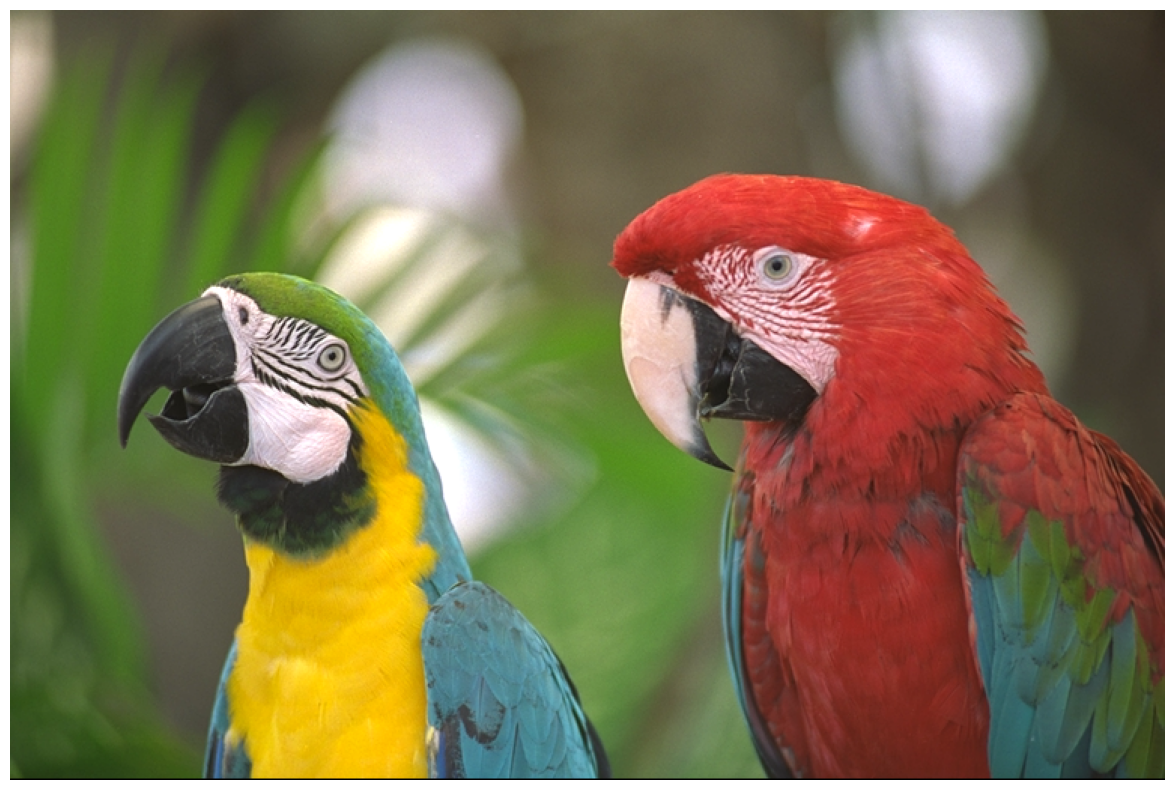

In [3]:
# Load image
img = cv2.imread('data/kodim23.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')
plt.show()

Let's start with gray tones first.

In [4]:
# Black, dark gray, light gray, white
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

Using the colour pallette, let's quantize the original image.

In [5]:
img = img.astype(np.float32)

rows, cols, channels = img.shape
quantized = np.zeros_like(img)

for r in range(rows):
    for c in range(cols):
        pixel = img[r, c, :]

        distances = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(distances)]

        quantized[r, c, :] = new_pixel

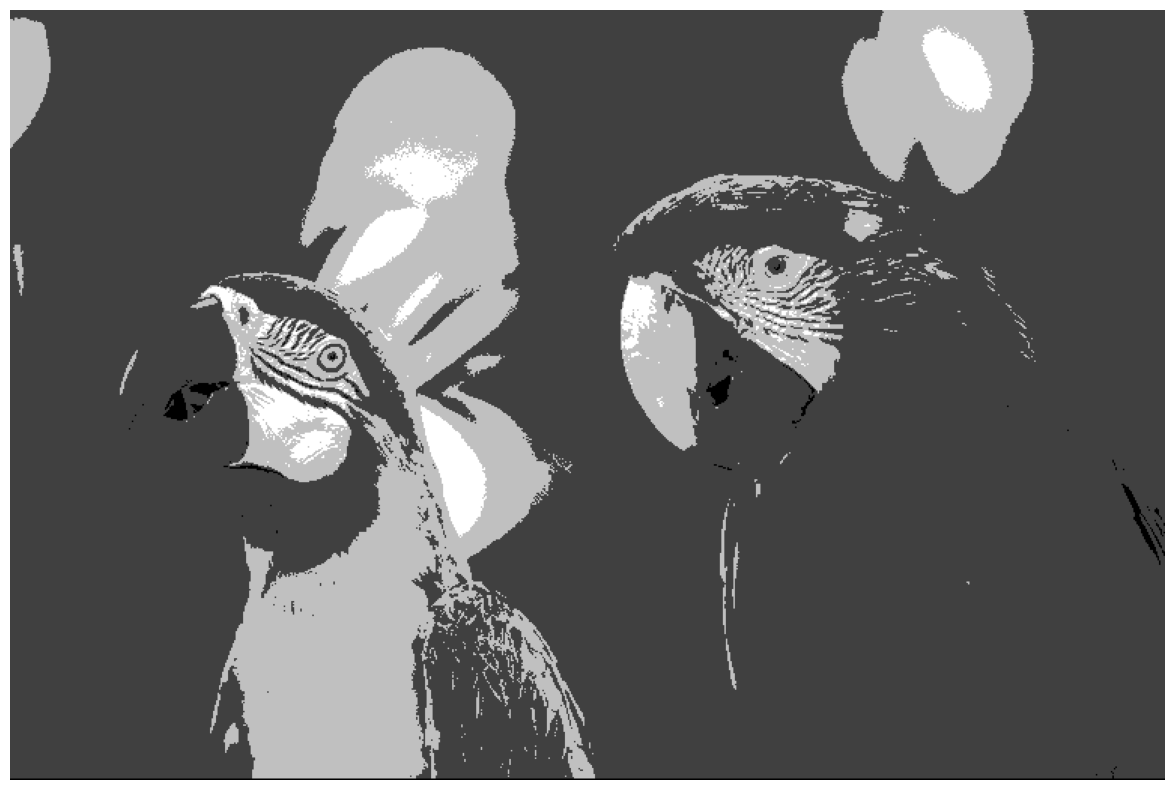

In [6]:
plt.imshow(quantized.astype(np.uint8))
plt.axis('off')
plt.show()

In [7]:
avg_quant_error = np.mean(np.linalg.norm(img - quantized, axis=2))
print('Average quantization error:', avg_quant_error)

Average quantization error: 67.73236


#### Floyd-Steinberg Dithering
We are now going to implement the FS dithering and compare it to the optimally quantized image we have calculated above.

In [8]:
# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = np.copy(img)
dithering = np.zeros_like(img)

for r in range(rows):
    for c in range(cols):
        pixel = img_tmp[r, c, :]

        distances = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(distances)]

        quant_error = pixel - new_pixel

        # Diffuse the quantization error according to the FS diffusion matrix
        if c + 1 < cols:
            img_tmp[r, c + 1, :] += quant_error * 7 / 16
        if r + 1 < rows:
            if c > 0:
                img_tmp[r + 1, c - 1, :] += quant_error * 3 / 16
            img_tmp[r + 1, c, :] += quant_error * 5 / 16
            if c + 1 < cols:
                img_tmp[r + 1, c + 1, :] += quant_error * 1 / 16

        dithering[r, c, :] = new_pixel

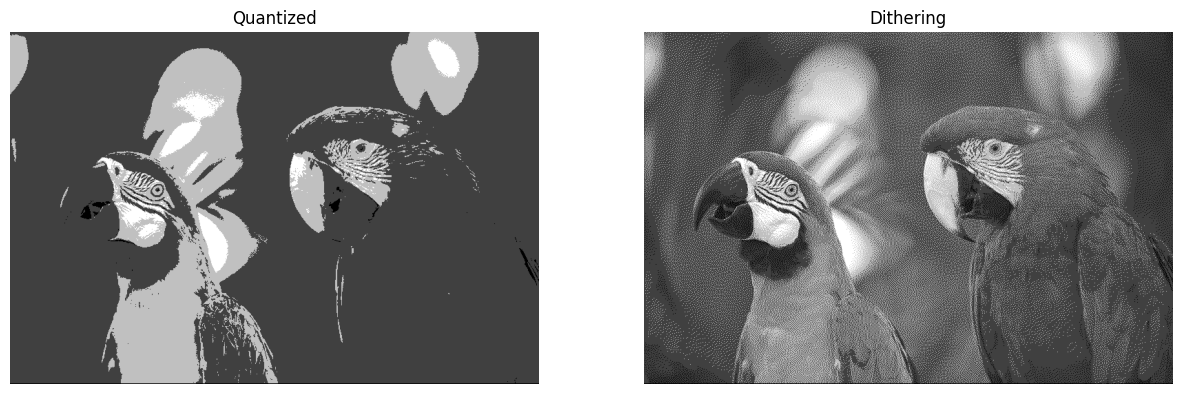

In [9]:
plt.subplot(121), plt.imshow(quantized.astype(np.uint8)), plt.title('Quantized')
plt.axis('off')
plt.subplot(122), plt.imshow(dithering.astype(np.uint8)), plt.title('Dithering')
plt.axis('off')
plt.show()

In [10]:
avg_dith_error = np.mean(np.linalg.norm(img - dithering, axis=2))
print('Average dithering error:', avg_dith_error)

Average dithering error: 81.842896


### Black and white palette

In [11]:
colors_bw = np.array([[0, 0, 0],
                      [255, 255, 255]])

quantized_bw = np.zeros_like(img)
dithering_bw = np.zeros_like(img)
img_tmp = np.copy(img)

for r in range(rows):
    for c in range(cols):
        pixel = img[r, c, :]
        distances = np.linalg.norm(colors_bw - pixel, axis=1)
        quantized_bw[r, c, :] = colors_bw[np.argmin(distances)]

        pixel = img_tmp[r, c, :]
        distances = np.linalg.norm(colors_bw - pixel, axis=1)
        new_pixel = colors_bw[np.argmin(distances)]
        quant_error = pixel - new_pixel

        if c + 1 < cols:
            img_tmp[r, c + 1, :] += quant_error * 7 / 16
        if r + 1 < rows:
            if c > 0:
                img_tmp[r + 1, c - 1, :] += quant_error * 3 / 16
            img_tmp[r + 1, c, :] += quant_error * 5 / 16
            if c + 1 < cols:
                img_tmp[r + 1, c + 1, :] += quant_error * 1 / 16

        dithering_bw[r, c, :] = new_pixel

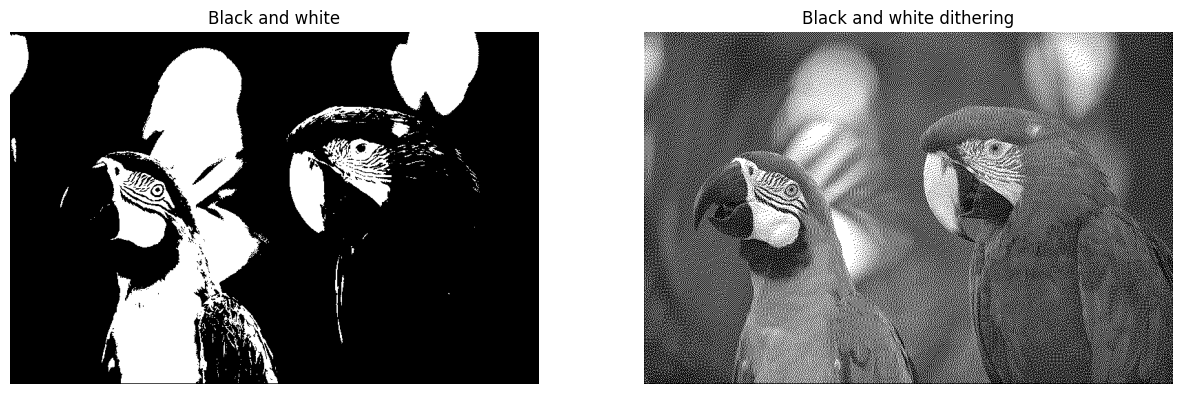

Average black and white quantization error: 152.54225
Average black and white dithering error: 193.21783


In [12]:
plt.subplot(121), plt.imshow(quantized_bw.astype(np.uint8)), plt.title('Black and white')
plt.axis('off')
plt.subplot(122), plt.imshow(dithering_bw.astype(np.uint8)), plt.title('Black and white dithering')
plt.axis('off')
plt.show()

avg_quant_error_bw = np.mean(np.linalg.norm(img - quantized_bw, axis=2))
avg_dith_error_bw = np.mean(np.linalg.norm(img - dithering_bw, axis=2))

print('Average black and white quantization error:', avg_quant_error_bw)
print('Average black and white dithering error:', avg_dith_error_bw)

### Bonus Points

For the bonus task, the colour palette is calculated using the K-means algorithm. The experiment is repeated for 16, 32 and 256 colours.

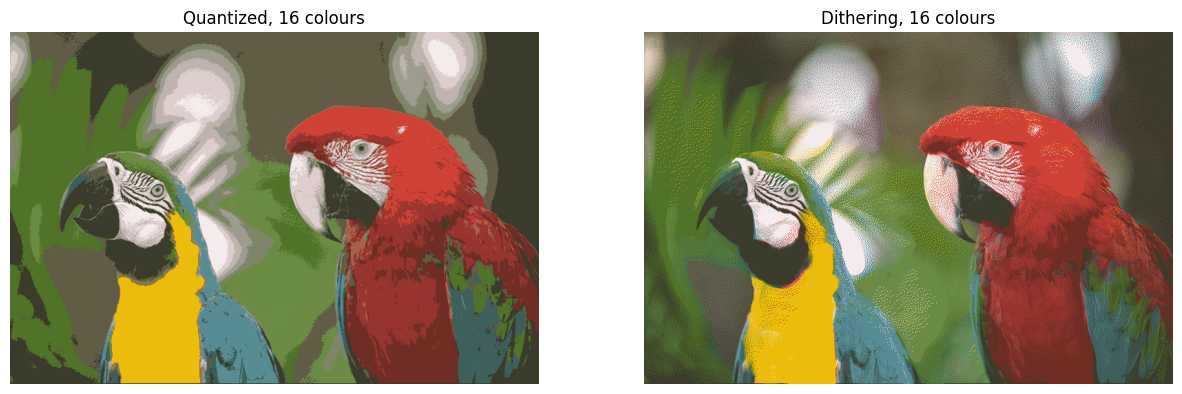

16 colours:
Average quantization error: 18.612337
Average dithering error: 31.540682



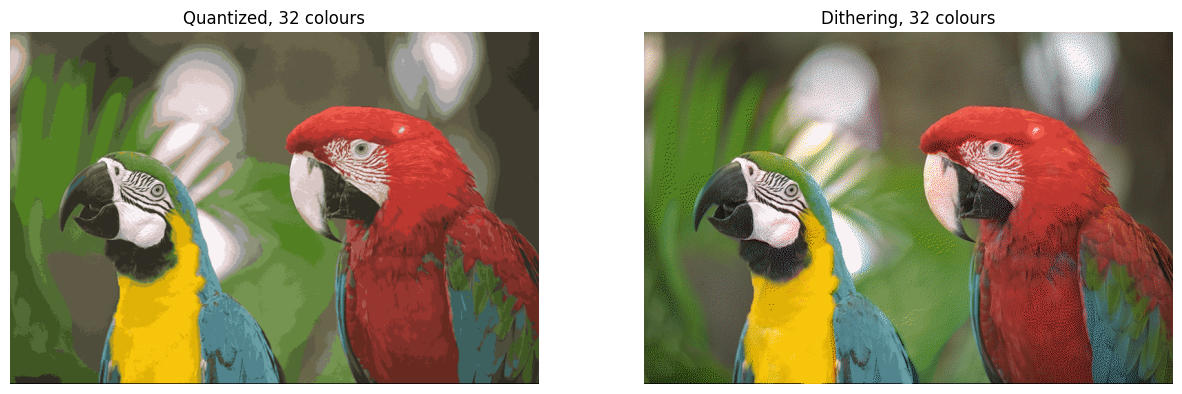

32 colours:
Average quantization error: 13.132938
Average dithering error: 28.10958



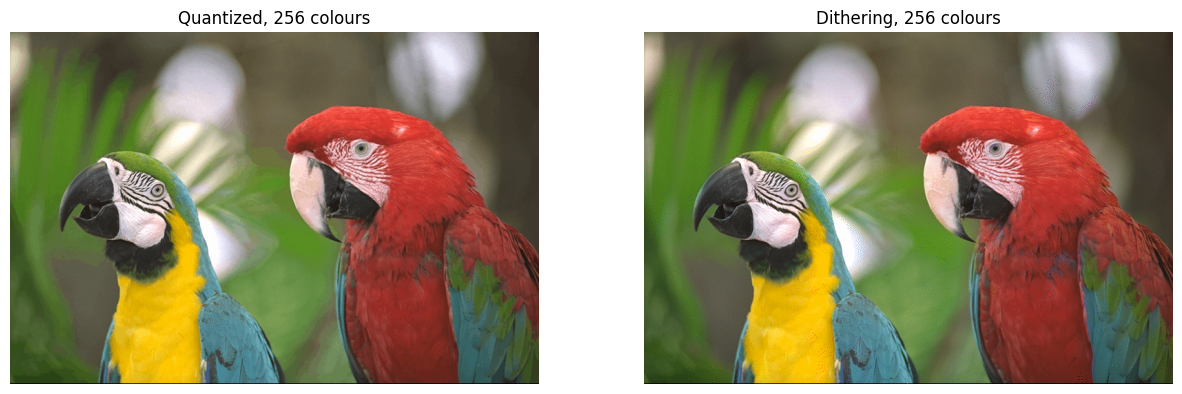

256 colours:
Average quantization error: 5.624639
Average dithering error: 9.255872



In [15]:
from sklearn.cluster import KMeans

pixels = img.reshape(-1, 3)

# We take every tenth pixel for K-means so that the calculation is faster.
# The obtained palette is then applied to the full-size image.
sample_pixels = pixels[::10]

bonus_errors = []

for number_of_colors in [16, 32, 256]:
    kmeans = KMeans(
        n_clusters=number_of_colors,
        random_state=0,
        n_init=1,
        max_iter=50
    )
    kmeans.fit(sample_pixels)
    colors_kmeans = kmeans.cluster_centers_

    quantized_kmeans = np.zeros_like(img)
    dithering_kmeans = np.zeros_like(img)
    img_tmp = np.copy(img)

    for r in range(rows):
        for c in range(cols):
            pixel = img[r, c, :]
            distances = np.linalg.norm(colors_kmeans - pixel, axis=1)
            quantized_kmeans[r, c, :] = colors_kmeans[np.argmin(distances)]

            pixel = img_tmp[r, c, :]
            distances = np.linalg.norm(colors_kmeans - pixel, axis=1)
            new_pixel = colors_kmeans[np.argmin(distances)]
            quant_error = pixel - new_pixel

            if c + 1 < cols:
                img_tmp[r, c + 1, :] += quant_error * 7 / 16
            if r + 1 < rows:
                if c > 0:
                    img_tmp[r + 1, c - 1, :] += quant_error * 3 / 16
                img_tmp[r + 1, c, :] += quant_error * 5 / 16
                if c + 1 < cols:
                    img_tmp[r + 1, c + 1, :] += quant_error * 1 / 16

            dithering_kmeans[r, c, :] = new_pixel

    avg_quant_error_kmeans = np.mean(
        np.linalg.norm(img - quantized_kmeans, axis=2)
    )
    avg_dith_error_kmeans = np.mean(
        np.linalg.norm(img - dithering_kmeans, axis=2)
    )

    bonus_errors.append([
        number_of_colors,
        avg_quant_error_kmeans,
        avg_dith_error_kmeans
    ])

    plt.figure(figsize=(15, 6))
    plt.subplot(121)
    plt.imshow(quantized_kmeans.astype(np.uint8))
    plt.title(f'Quantized, {number_of_colors} colours')
    plt.axis('off')

    plt.subplot(122)
    plt.imshow(dithering_kmeans.astype(np.uint8))
    plt.title(f'Dithering, {number_of_colors} colours')
    plt.axis('off')
    plt.show()

    print(f'{number_of_colors} colours:')
    print('Average quantization error:', avg_quant_error_kmeans)
    print('Average dithering error:', avg_dith_error_kmeans)
    print()